Practical Aspects of Training CNN for Image Classification
Task.  

**Task 1: Data Understanding and Visualization:**

TensorFlow version: 2.19.0
Classes found (6): ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


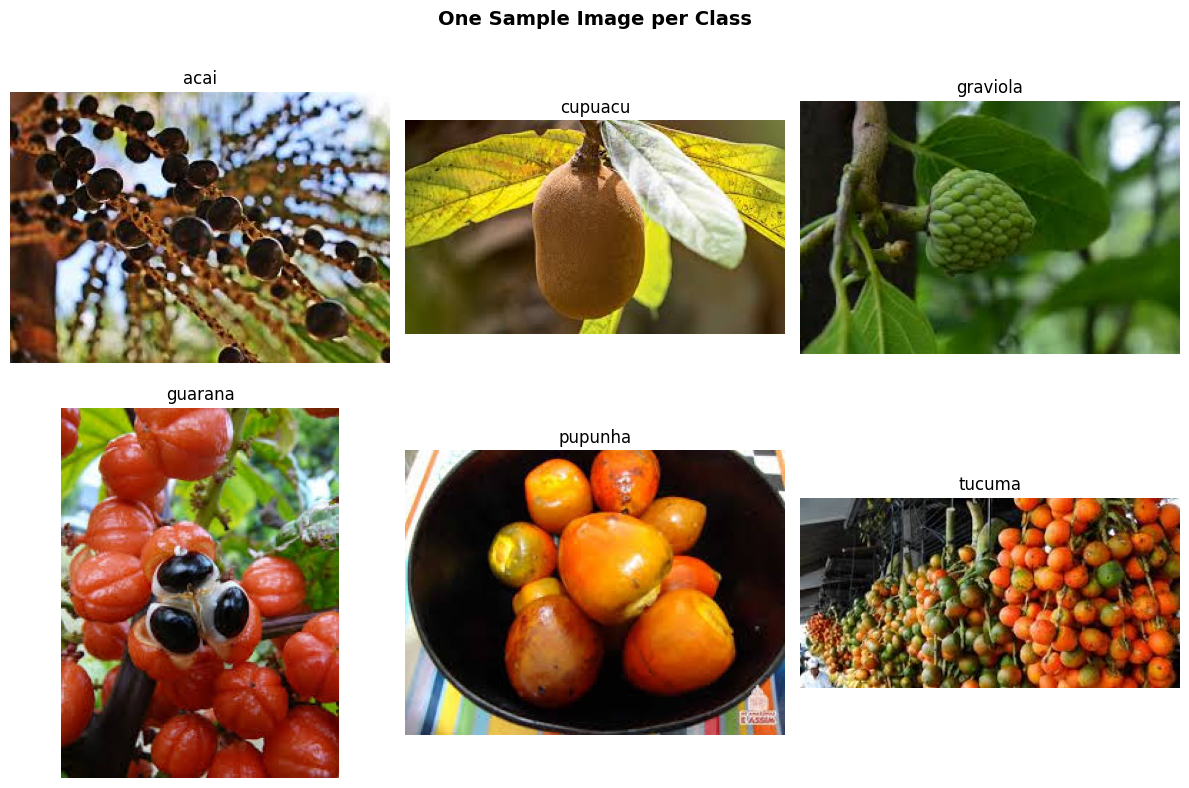


Observations:
- The dataset contains 6 Amazon fruit classes: pupunha, guarana, graviola, tucuma, acai, cupuacu.
- Images vary significantly in size, background, lighting, and color.
- Some classes (e.g., acai) have very distinct colors; others may be harder to distinguish.
- Preprocessing (resize + normalize) is essential before training.



In [1]:
# import os
# import random
# import numpy as np
# import matplotlib.pyplot as plt
# import tensorflow as tf
# from tensorflow import keras
# from tensorflow.keras import layers
# from PIL import Image
# from sklearn.metrics import classification_report

# # Paths - update these to match your dataset location
# train_dir = "/content/drive/MyDrive/Week 5 AI ML/FruitinAmazon/train"
# test_dir  = "/content/drive/MyDrive/Week 5 AI ML/FruitinAmazon/test"
# # Hyperparameters
# IMG_HEIGHT    = 128
# IMG_WIDTH     = 128
# BATCH_SIZE    = 16
# EPOCHS        = 250
# VALIDATION_SPLIT = 0.2
# SEED          = 123

# print('TensorFlow version:', tf.__version__)

# # Get class directories from train folder
# class_dirs = sorted([
#     d for d in os.listdir(train_dir)
#     if os.path.isdir(os.path.join(train_dir, d))
# ])
# num_classes = len(class_dirs)
# print(f'Classes found ({num_classes}):', class_dirs)

# # Select one random image per class
# sample_images = []
# sample_labels = []
# for cls in class_dirs:
#     cls_path = os.path.join(train_dir, cls)
#     images   = [f for f in os.listdir(cls_path)
#                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
#     if images:
#         chosen = random.choice(images)
#         sample_images.append(os.path.join(cls_path, chosen))
#         sample_labels.append(cls)

# # Display in a 2-row grid
# cols = (num_classes + 1) // 2
# fig, axes = plt.subplots(2, cols, figsize=(cols * 4, 8))
# axes = axes.flatten()

# for i, (img_path, label) in enumerate(zip(sample_images, sample_labels)):
#     img = Image.open(img_path)
#     axes[i].imshow(img)
#     axes[i].set_title(label, fontsize=12)
#     axes[i].axis('off')

# # Hide unused axes
# for j in range(i + 1, len(axes)):
#     axes[j].axis('off')

# plt.suptitle('One Sample Image per Class', fontsize=14, fontweight='bold')
# plt.tight_layout()
# plt.show()

# print("""
# Observations:
# - The dataset contains 6 Amazon fruit classes: pupunha, guarana, graviola, tucuma, acai, cupuacu.
# - Images vary significantly in size, background, lighting, and color.
# - Some classes (e.g., acai) have very distinct colors; others may be harder to distinguish.
# - Preprocessing (resize + normalize) is essential before training.
# """)

Classes found (6): ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


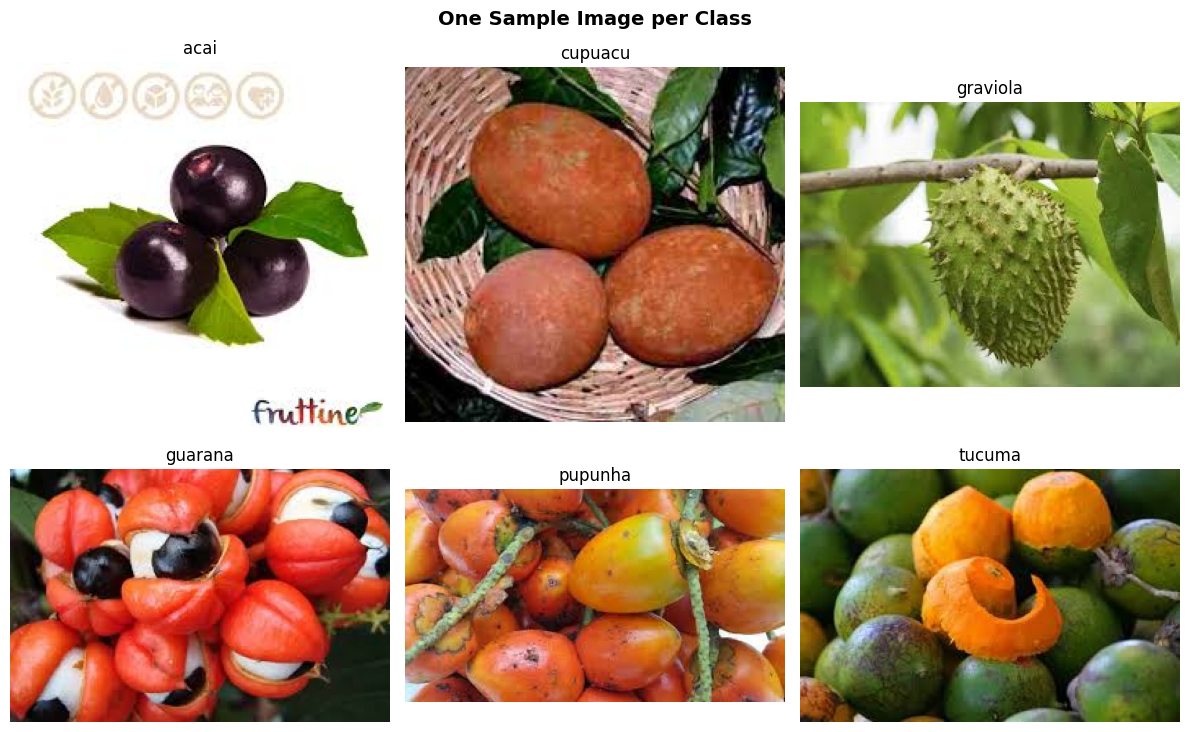


Observations:
- The dataset contains 6 Amazon fruit classes: pupunha, guarana, graviola, tucuma, acai, cupuacu.
- Images vary significantly in size, background, lighting, and color.
- Some classes (e.g., acai) have very distinct colors; others may be harder to distinguish.
- Preprocessing (resize + normalize) is essential before training.



In [2]:
# Get class directories from train folder
class_dirs = sorted([
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d))
])
num_classes = len(class_dirs)
print(f'Classes found ({num_classes}):', class_dirs)

# Select one random image per class
sample_images = []
sample_labels = []
for cls in class_dirs:
    cls_path = os.path.join(train_dir, cls)
    images   = [f for f in os.listdir(cls_path)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if images:
        chosen = random.choice(images)
        sample_images.append(os.path.join(cls_path, chosen))
        sample_labels.append(cls)

# Display in a 2-row grid
cols = (num_classes + 1) // 2
fig, axes = plt.subplots(2, cols, figsize=(cols * 4, 8))
axes = axes.flatten()

for i, (img_path, label) in enumerate(zip(sample_images, sample_labels)):
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(label, fontsize=12)
    axes[i].axis('off')

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('One Sample Image per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
Observations:
- The dataset contains 6 Amazon fruit classes: pupunha, guarana, graviola, tucuma, acai, cupuacu.
- Images vary significantly in size, background, lighting, and color.
- Some classes (e.g., acai) have very distinct colors; others may be harder to distinguish.
- Preprocessing (resize + normalize) is essential before training.
""")

**Task 1.2: Check Corrupted Images**

In [3]:
corrupted = []

for cls in class_dirs:
    cls_path = os.path.join(train_dir, cls)
    for fname in os.listdir(cls_path):
        img_path = os.path.join(cls_path, fname)
        try:
            img = Image.open(img_path)
            img.verify()          # Checks file integrity
        except (IOError, SyntaxError):
            corrupted.append(img_path)
            os.remove(img_path)
            print(f'Removed corrupted image: {img_path}')

if not corrupted:
    print('No Corrupted Images Found.')
else:
    print(f'Total corrupted images removed: {len(corrupted)}')

No Corrupted Images Found.


**Task 3: Load Dataset**

In [4]:
rescale = tf.keras.layers.Rescaling(1.0 / 255)  # Normalize to [0, 1]

# Training dataset
raw_train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=VALIDATION_SPLIT,
    subset='training',
    seed=SEED
)
train_ds = raw_train_ds.map(lambda x, y: (rescale(x), y))

# Validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False,
    validation_split=VALIDATION_SPLIT,
    subset='validation',
    seed=SEED
)
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

# Test dataset (no split needed)
raw_test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False
)
test_ds = raw_test_ds.map(lambda x, y: (rescale(x), y))

# Class names from the dataset
class_names = raw_train_ds.class_names
num_classes = len(class_names)
print('Class names:', class_names)
print('Number of classes:', num_classes)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


**Task3: CNN Model**

In [5]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# 1. LOAD DATASET
train_dir = "/content/drive/MyDrive/Week 5 AI ML/FruitinAmazon/train"

image_size = (224, 224)
batch_size = 32

train_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size
)

val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)

# 2. DATA AUGMENTATION

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.1),
])


# 3. BUILD CNN MODEL

model = keras.Sequential([
    layers.Input(shape=(224, 224, 3)),

    # Augmentation + Scaling
    data_augmentation,
    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    # Block 4
    layers.Conv2D(256, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.4),

    # Dense Layers
    layers.Flatten(),
    layers.Dense(512),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    # Output
    layers.Dense(num_classes, activation='softmax')
])


# 4. COMPILE MODEL

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# 5. TRAIN MODEL

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

# 6. EVALUATION

loss, acc = model.evaluate(val_ds)
print(f"Validation Accuracy: {acc:.4f}")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             

 Total params: 26,216,902 (100.01 MB)

 Trainable params: 26,214,406 (100.00 MB)

 Non-trainable params: 2,496 (9.75 KB)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 28s 6s/step - accuracy: 0.1667 - loss: 2.4206 - val_accuracy: 0.1667 - val_loss: 1.9402
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 30s 11s/step - accuracy: 0.4167 - loss: 1.7675 - val_accuracy: 0.1667 - val_loss: 1.7648
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 33s 6s/step - accuracy: 0.4306 - loss: 1.5046 - val_accuracy: 0.2778 - val_loss: 1.7031
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 6s/step - accuracy: 0.5278 - loss: 1.4238 - val_accuracy: 0.2778 - val_loss: 1.6769
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 6s/step - accuracy: 0.5000 - loss: 1.4009 - val_accuracy: 0.2778 - val_loss: 1.6791
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 5s/step - accuracy: 0.5000 - loss: 1.3852 - val_accuracy: 0.2778 - val_loss: 1.6794
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 0.5694 - loss: 1.1258 - val_accuracy: 0.2778 - val_loss: 1.7167
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 6s/step - accuracy: 0.6528 - loss: 0.9046 - val_accuracy: 0.2222 - val_loss: 1.6944
Epoch 9

**Task 4: Compile and Train the Model**

In [6]:
# ── Compile ───────────────────────────────────────────────────
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ── Callbacks ─────────────────────────────────────────────────
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    filepath='best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop_cb = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,          # Stop if no improvement for 20 epochs
    restore_best_weights=True,
    verbose=1
)

# ── Train ─────────────────────────────────────────────────────
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=[checkpoint_cb, early_stop_cb]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8322 - loss: 0.4443
Epoch 1: val_accuracy improved from None to 0.22222, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 28s 6s/step - accuracy: 0.7778 - loss: 0.5050 - val_accuracy: 0.2222 - val_loss: 3.4157
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8200 - loss: 0.5827
Epoch 2: val_accuracy did not improve from 0.22222
3/3 ━━━━━━━━━━━━━━━━━━━━ 39s 5s/step - accuracy: 0.8194 - loss: 0.6092 - val_accuracy: 0.2222 - val_loss: 3.5792
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8206 - loss: 0.5841
Epoch 3: val_accuracy did not improve from 0.22222
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 0.8056 - loss: 0.6503 - val_accuracy: 0.2222 - val_loss: 3.4898
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8461 - loss: 0.4362
Epoch 4: val_accuracy did not improve from 0.22222
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 6s/step - accuracy: 0.8194 - loss: 0.4939 - val_accuracy: 0.2222 - val_loss: 3.1989
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7940 - loss: 0.5422
Epoch 5: val_accur

In [7]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

# Load pre-trained model
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze layers
for layer in base_model.layers:
    layer.trainable = False

# Custom classifier
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(120, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=outputs)

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# Evaluate
loss, acc = model.evaluate(val_ds)
print(f"Transfer Learning Accuracy: {acc:.4f}")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 52s 16s/step - accuracy: 0.2083 - loss: 8.7664 - val_accuracy: 0.1111 - val_loss: 5.4499
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 91s 21s/step - accuracy: 0.3056 - loss: 5.5715 - val_accuracy: 0.3889 - val_loss: 4.4726
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 74s 17s/step - accuracy: 0.3472 - loss: 4.6421 - val_accuracy: 0.4444 - val_loss: 4.1273
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 51s 16s/step - accuracy: 0.5833 - loss: 2.4965 - val_accuracy: 0.3889 - val_loss: 3.4604
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 83s 16s/step - accuracy: 0.5556 - loss: 2.4907 - val_accuracy: 0.4444 - val_loss: 2.6561
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 51s 16s/step - accuracy: 0.6528 - loss: 1.6929 - val_accuracy: 0.5000 - val_loss: 2.2137
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 91s 21s/step - accuracy: 0.7083 - loss: 1.4977 - val_accuracy: 0.4444 - val_loss: 2.2796
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 59s 21s/step - accuracy: 0.8333 - loss

**Task 5: Evaluate the Model**

In [16]:
test_loss, test_acc = loaded_model.evaluate(test_ds)
print(f'\nTest Loss    : {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 17s 17s/step - accuracy: 0.5667 - loss: 2.0180

Test Loss    : 2.0180
Test Accuracy: 0.5667


In [9]:
# Recreate test_ds with the correct image size and batch size for the transfer learning model
# Use the image_size and batch_size consistent with the model training in cell ghU0B8JSifd1
test_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(224, 224),
    batch_size=32, # This matches the batch_size used for training the transfer learning model
    shuffle=False
)

Found 30 files belonging to 6 classes.


In [10]:
for images, labels in test_ds.take(1):
    print("Shape of images in test_ds:", images.shape)
    print("Shape of labels in test_ds:", labels.shape)
    break

Shape of images in test_ds: (30, 224, 224, 3)
Shape of labels in test_ds: (30,)


**Task 6: Save and Load the Model**

In [12]:
# Save
model.save('fruits_cnn_model.h5')
print('Model saved as fruits_cnn_model.h5')

# Load
loaded_model = keras.models.load_model('fruits_cnn_model.h5')
print('Model loaded successfully!')

loaded_loss, loaded_acc = loaded_model.evaluate(test_ds)
print(f'\nLoaded Model — Test Loss: {loaded_loss:.4f} | Test Accuracy: {loaded_acc:.4f}')

Model saved as fruits_cnn_model.h5


Model loaded successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step - accuracy: 0.5667 - loss: 2.0180

Loaded Model — Test Loss: 2.0180 | Test Accuracy: 0.5667


**Task 7: Predictions and Classification Report**

In [13]:
# Collect all true labels and predictions from the test set
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = loaded_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Classification Report
print('\n── Classification Report ──────────────────────────────\n')
print(classification_report(y_true, y_pred, target_names=class_names))


── Classification Report ──────────────────────────────

              precision    recall  f1-score   support

        acai       0.60      0.60      0.60         5
     cupuacu       0.75      0.60      0.67         5
    graviola       1.00      0.60      0.75         5
     guarana       0.71      1.00      0.83         5
     pupunha       0.00      0.00      0.00         5
      tucuma       0.38      0.60      0.46         5

    accuracy                           0.57        30
   macro avg       0.57      0.57      0.55        30
weighted avg       0.57      0.57      0.55        30



**Visualise a Sample of Predictions**

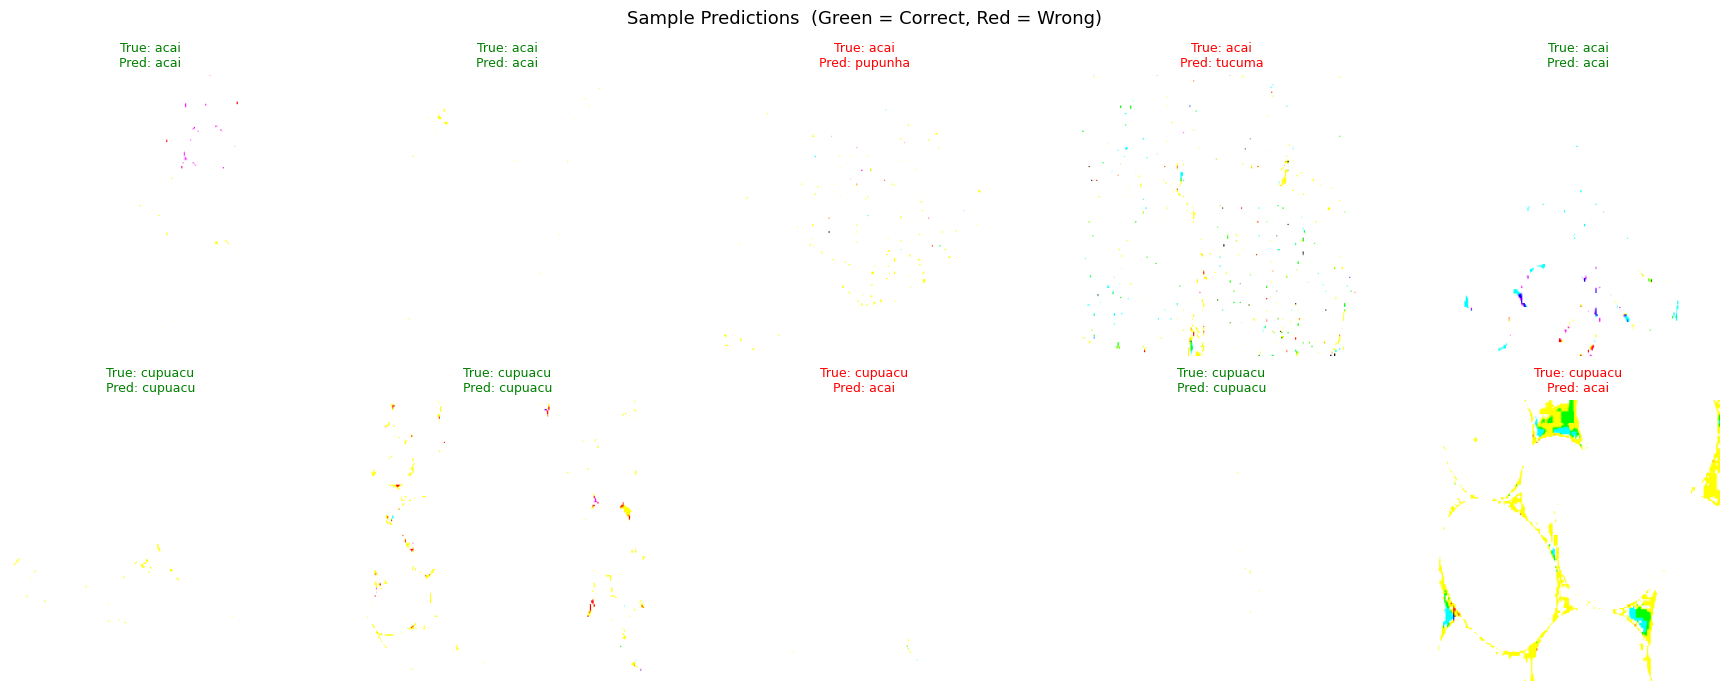

In [14]:
# Show first 10 test images with predicted vs true label
sample_images_batch, sample_labels_batch = next(iter(test_ds))
sample_preds = loaded_model.predict(sample_images_batch, verbose=0)
sample_pred_labels = np.argmax(sample_preds, axis=1)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i in range(10):
    axes[i].imshow(sample_images_batch[i].numpy())
    true_lbl = class_names[sample_labels_batch[i]]
    pred_lbl = class_names[sample_pred_labels[i]]
    color = 'green' if true_lbl == pred_lbl else 'red'
    axes[i].set_title(f'True: {true_lbl}\nPred: {pred_lbl}', color=color, fontsize=9)
    axes[i].axis('off')

plt.suptitle('Sample Predictions  (Green = Correct, Red = Wrong)', fontsize=13)
plt.tight_layout()
plt.show()